Title: Surface_Wind_average.ipynb

Purpose: Calculate a wind speed average and find periods of wind minima

Author: Onno Nennecke on 22 January 2025 Modified: 22 January 2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

Import packages

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Load data

In [7]:
ESM = 'CESM2' 
run = 'r1i1p1f1' # r10i1p1f1  r11i1p1f1  r1i1p1f1  r2i1p1f1  r3i1p1f1  r4i1p1f1  r5i1p1f1  r6i1p1f1  r7i1p1f1  r8i1p1f1  r9i1p1f1
variable = 'sfcWind' # Surface Wind Speed
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*')

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

In [8]:
nc

<xarray.Dataset> Size: 14GB
Dimensions:    (time: 60226, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    sfcWind    (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    time_bnds  (time, nbnd) object 964kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float32 93MB dask.array<chunksize=(3650, 192, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float32 139MB dask.array<chunksize=(3650, 288, 2), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T22:00:26Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [9]:
# select variable
sfcWind = nc['sfcWind'] 
sfcWind
# filter winter
sfcWind = sfcWind[np.isin(sfcWind.time.dt.month, [10,11,12,1,2,3]),:,:]
sfcWind
# select region
sfcWind = sfcWind.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
sfcWind

<xarray.DataArray 'sfcWind' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 10 meters) wind speed.
    description:    near-surface (usually, 10 meters) wind speed.
    frequency:      day
    id:             sfcWind
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Daily-Mean Near-Surface Wind Speed
    type:           real
    units:          m s-1
    variable_id:    sfcWind

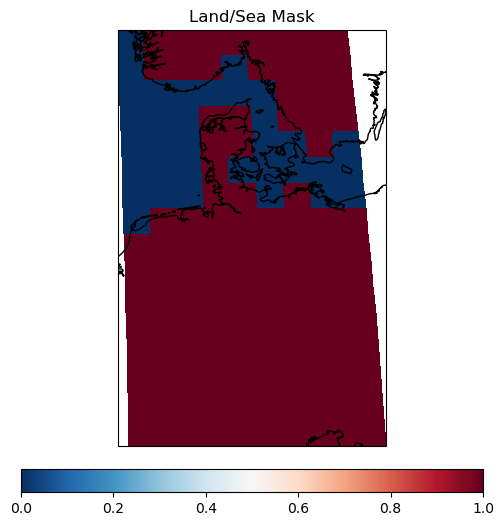

In [10]:

import regionmask
land_sea_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110
# land_sea_mask
mask = land_sea_mask.mask(sfcWind)
boolean_mask = mask.notnull()  # Land = True, Sea = False

fig, (ax1) = plt.subplots(nrows=1, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

ax1.coastlines()
xxx = boolean_mask
im1 = ax1.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.PlateCarree(), cmap='RdBu_r')
ax1.set_title('Land/Sea Mask')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, fraction=0.05)

plt.show()

In [11]:
# Calculate power from wind speed

alpha_on = 1/7 # Roughness parameter onshore
alpha_off = 0.11 # Roughness parameter offshore
hub_height_on = 80 # Approximation: Onshore 80 m
hub_height_off = 120 # Approximation: Offshore 120 m
ref_height = 10 # Height of wind data
v_cut_in = 3.5 # Minimum wind speed to start producing power
v_cut_out = 25 # Maximum wind speed to produce power
v_rated = 13 # Wind speed at which the turbine produces maximum power

scaling_factors = (
    boolean_mask * (hub_height_on / ref_height) ** alpha_on +
    (~boolean_mask) * (hub_height_off / ref_height) ** alpha_off
)

# Calculate wind speed at hub height
sfcWind_at_height = sfcWind * scaling_factors

# Oldcode for single value (and understanding)
""" def calc_wind_power(sfcWind_cell):
    sfcWind_at_height = sfcWind_cell * (hub_height / ref_height)**alpha
    if sfcWind_at_height < v_cut_in:
        return 0
    elif v_cut_in <= sfcWind_at_height < v_rated:
        return (sfcWind_at_height**3 - v_cut_in**3) / (v_rated**3 - v_cut_in**3)
    elif v_rated <= sfcWind_at_height < v_cut_out:
        return 1
    elif v_cut_out <= sfcWind_at_height:
        return 0
    else:
        raise ValueError('Something went wrong')
 """
 
# Vectorized version
def calc_wind_power(wind):
    
    # Initialize output array
    power = np.zeros_like(wind)

    # Calculate power using vectorized conditions
    in_range_cut_in = (wind >= v_cut_in) & (wind < v_rated)
    in_range_rated = (wind >= v_rated) & (wind < v_cut_out)

    # Apply the formula for the different wind speed ranges
    power[in_range_cut_in] = ((wind[in_range_cut_in]**3 - v_cut_in**3) /
                              (v_rated**3 - v_cut_in**3))
    power[in_range_rated] = 1  # Full power

    # Return the computed power array
    return power



In [12]:
wind_power = xr.apply_ufunc(calc_wind_power, sfcWind_at_height, dask='parallelized') # , output_dtypes=[float]
wind_power

<xarray.DataArray (time: 30031, lat: 16, lon: 9)> Size: 35MB
dask.array<transpose, shape=(30031, 16, 9), dtype=float64, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

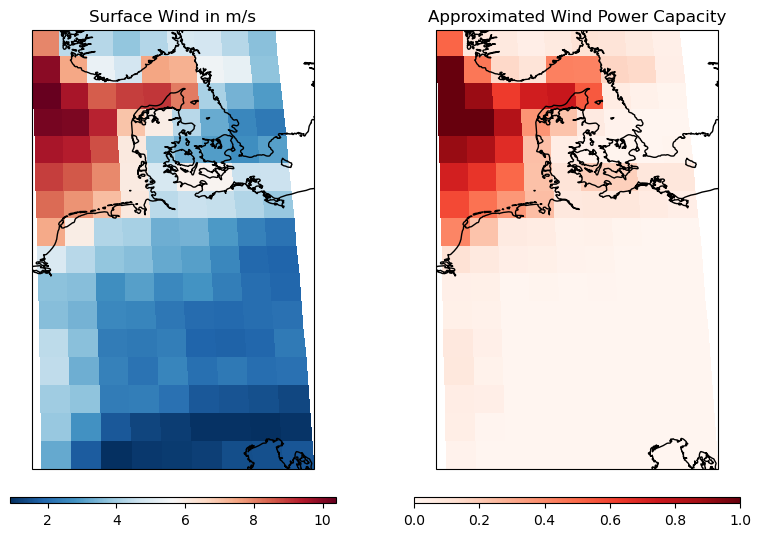

In [15]:
lon_edges = sfcWind.lon.values - (sfcWind.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = sfcWind.lat.values - (sfcWind.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')



# Plot the data
timestep = 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
xxx = sfcWind.isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx, transform=ccrs.PlateCarree(), cmap='RdBu_r')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')


# Second subplot
ax2.coastlines()
xxx = wind_power.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx, transform=ccrs.PlateCarree(), cmap='Reds')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()

In [10]:
# Here we would need installed capacity data

In [ ]:
# Solar capacity:
variable = 'rsds' # Surface Downwelling Shortwave Radiation
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*')
# select variable
rsds = nc['rsds'] 
rsds
# filter winter
rsds = rsds[np.isin(rsds.time.dt.month, [10,11,12,1,2,3]),:,:]
rsds
# select region
rsds = rsds.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
rsds

<xarray.DataArray 'rsds' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/20)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        Surface solar irradiance for UV calculations.
    description:    Surface solar irradiance for UV calculations.
    frequency:      day
    id:             rsds
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Surface Downwelling Shortwave Radiation
    type:           real
    units:          W m-2
    variable_id:    rsds

In [7]:
# Temperature:
variable = 'tas' # 
nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*')
# select variable
tas = nc['tas'] 
tas
# filter winter
tas = tas[np.isin(tas.time.dt.month, [10,11,12,1,2,3]),:,:]
tas
# select region
tas = tas.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
tas

<xarray.DataArray 'tas' (time: 30031, lat: 16, lon: 9)> Size: 17MB
dask.array<getitem, shape=(30031, 16, 9), dtype=float32, chunksize=(1, 16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      day
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

In [1]:
# Calculate solar capacity
gamma = -0.005 # 
Tref = 25 # 
c_1 = 4.3 #
c_2 = 0.943 #
c_3 = 0.028 #
c_4 = -1.528 #

In [2]:
# T_a_day = (T_a_mean + T_a_max) / 2 # ??? 
T_a_day = tas

NameError: name 'tas' is not defined

In [ ]:
T_cell = c_1 + c_2 * T_a_day + c_3 * rsds + c_4 * sfcWind

In [ ]:
P_R = 1 + gamma * (T_cell - Tref)

In [ ]:
PV_pot = P_R * (G / G_stc)

In [ ]:
# Apply weighted mean (to wind)
weights = np.cos(np.radians(sfcWind.lat))
sfcWind_reg_avg = sfcWind.weighted(weights).mean(('lat','lon'))
sfcWind_reg_avg

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
dask.array<truediv, shape=(30031,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [ ]:
# Zwischenergebnis speichern
xr.Dataset({'sfcWind':sfcWind_reg_avg}).to_netcdf('/climca/people/onennecke/sfcWind_reg_mean.nc')

In [12]:
sfcWind_reg_avg = xr.open_dataarray('/climca/people/onennecke/sfcWind_reg_mean.nc')
sfcWind_reg_avg

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
[30031 values with dtype=float64]
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [27]:
# Apply weighted mean to capacity factors
weights = np.cos(np.radians(wind_power.lat))
wind_power_reg_avg = wind_power.weighted(weights).mean(('lat','lon'))


In [28]:
wind_power_reg_avg.values[1]

np.float64(0.27049253385955857)

In [29]:
# Identification of low wind energy periods
event_duration = 3 # days
threshold = 0.01 # m/s

low_wind_energy = wind_power_reg_avg.where(wind_power_reg_avg < threshold, drop=False)

In [30]:
# wind_power_reg_avg
nan_count = np.isnan(low_wind_energy.values).sum()

nan_count

np.int64(29963)

In [31]:
low_wind_energy

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
dask.array<where, shape=(30031,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [32]:
# First Method: Constantly-BelowThreshold (CBT)
threshold =  0.01 # m/s

low_wind_energy = sfcWind_reg_avg.where(sfcWind_reg_avg < threshold, drop=False)
low_wind_energy

<xarray.DataArray 'sfcWind' (time: 30031)> Size: 240kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(30031,))
Coordinates:
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [33]:
# aufpassen mit Feb -> Dez
sfcWind_reg_avg_roll = sfcWind_reg_avg.rolling(time=7, center=False).mean()

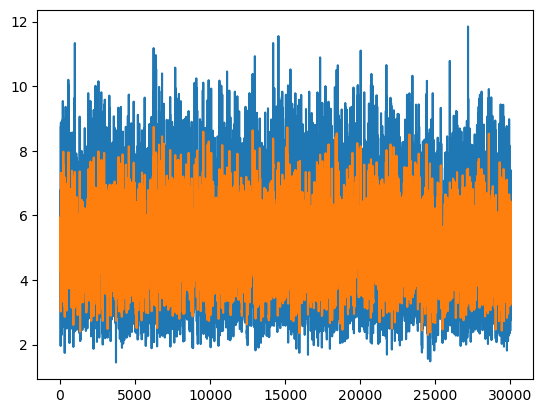

In [20]:
plt.plot(sfcWind_reg_avg)
plt.plot(sfcWind_reg_avg_roll)

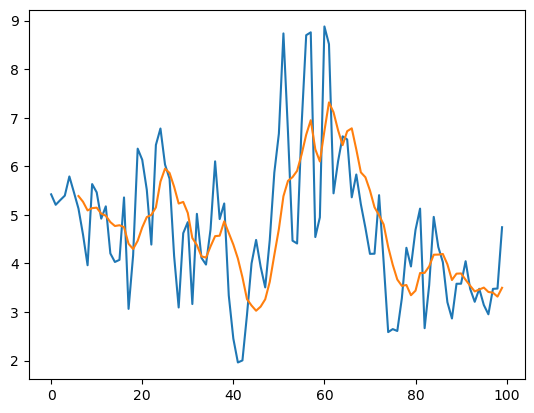

In [21]:
plt.plot(sfcWind_reg_avg[:100])
plt.plot(sfcWind_reg_avg_roll[:100])

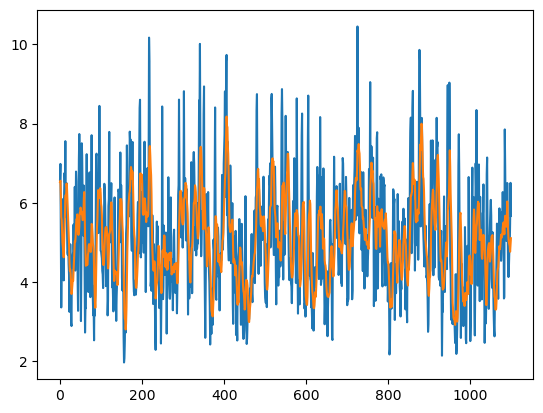

In [22]:
plt.plot(sfcWind_reg_avg[10400:11500])
plt.plot(sfcWind_reg_avg_roll[10400:11500])

In [23]:
# Find weeks with lowest average wind speed
lowest_indices = np.argsort(sfcWind_reg_avg_roll.values)[:10]
lowest_indices
# sfcWind_reg_avg_roll[lowest_indices]

array([24506, 24504, 24505, 15944, 24658,  1337, 24657, 15943, 24507,
       29420])

In [24]:
# !!! not yet possible as for other simulation run -- not comparable
# plot PSL and Z500 maps for 10 most extreme temperatures

variable = 'PSL' # Temperature at Reference Height
nc_psl = xr.open_mfdataset(f'/climca/data/CESM2_LE/{variable}/day_raw/b.e21.{ESM}.f09_g17.{run}.cam.h1.{variable}.*')

In [16]:
nc_psl

<xarray.Dataset> Size: 13GB
Dimensions:       (time: 60226, lat: 192, lev: 32, ilev: 33, nbnd: 2, lon: 288)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:0...
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (time, lat) float64 93MB dask.array<chunksize=(3650, 192), meta=np.ndarray>
    hyam          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    hybm          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    P0            (time) float64 482kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    hybi          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f11vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f12vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    sol_tsi       (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    nsteph        (time) float64 482kB dask.array<chunksize=(1024,), meta=np.ndarray>
    PSL           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTcmip6.f09_g17.LE2-1001.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1001-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [25]:
nc_psl

# select variable
psl = nc_psl['PSL'] # Pressure at Sea Level

# filter winter
psl = psl[np.isin(psl.time.dt.month, [12,1,2]),:,:]
# psl

# select region
psl_1 = psl.sel(dict(lat=slice(10,90), lon= slice(280,360)))
psl_2 = psl.sel(dict(lat=slice(10,90), lon= slice(0,40)))

psl = xr.concat([psl_1, psl_2], dim='lon')


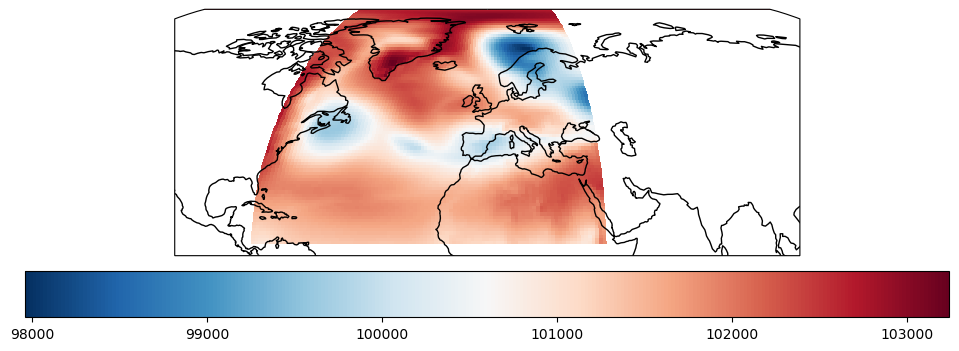

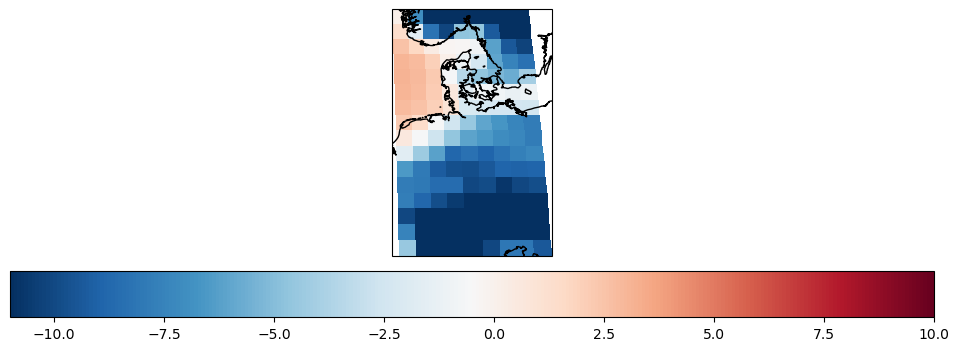

In [26]:
timestep = 11450

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': ccrs.crs.Robinson()})
ax.coastlines()
xxx = psl.isel(time=timestep)
im = ax.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.crs.PlateCarree(), cmap='RdBu_r')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': ccrs.crs.Robinson()})
ax.coastlines()
xxx = sfcWind.isel(time=timestep)

vmin = -11
vmax = 10

im = ax.pcolormesh(xxx.lon, xxx.lat, xxx - 273.15, transform=ccrs.crs.PlateCarree(), cmap='RdBu_r', vmin=vmin,vmax=vmax)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)


In [27]:
sfcWind.isel(time=11450)

<xarray.DataArray 'TREFHT' (lat: 16, lon: 9)> Size: 576B
dask.array<getitem, shape=(16, 9), dtype=float32, chunksize=(16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    time     object 8B 1977-01-21 00:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean